In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [21]:
df = pd.read_csv("new_insurance.csv")

In [22]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [23]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(1338, 7)

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [24]:
X = df.drop("charges", axis=1)

y = df["charges"]


In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
# 1. Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = lr_mse ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

In [28]:
# 2. Decision Tree

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = dt_mse ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

In [29]:
# 3. Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

In [30]:
# 4. AdaBoost

ada = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

ada_mae = mean_absolute_error(y_test, ada_pred)
ada_mse = mean_squared_error(y_test, ada_pred)
ada_rmse = ada_mse ** 0.5
ada_r2 = r2_score(y_test, ada_pred)

In [31]:
# 5. Gradient Boosting

gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = gb_mse ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

In [32]:
# 6. Extra Trees

et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

et_mae = mean_absolute_error(y_test, et_pred)
et_mse = mean_squared_error(y_test, et_pred)
et_rmse = et_mse ** 0.5
et_r2 = r2_score(y_test, et_pred)

In [33]:
#  Display Results

print("\nMODEL PERFORMANCE")

print("\nLinear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

print("\nDecision Tree")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

print("\nRandom Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

print("\nAdaBoost")
print("MAE:", ada_mae)
print("RMSE:", ada_rmse)
print("R2 Score:", ada_r2)

print("\nGradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

print("\nExtra Trees")
print("MAE:", et_mae)
print("RMSE:", et_rmse)
print("R2 Score:", et_r2)



MODEL PERFORMANCE

Linear Regression
MAE: 4181.19447375365
RMSE: 5796.284659276273
R2 Score: 0.7835929767120724

Decision Tree
MAE: 3195.1104733805973
RMSE: 6515.129162967606
R2 Score: 0.7265877305258355

Random Forest
MAE: 2550.0784706115096
RMSE: 4576.299916157115
R2 Score: 0.8651034329144947

AdaBoost
MAE: 4421.259250654506
RMSE: 5267.060510339545
R2 Score: 0.8213065823275452

Gradient Boosting
MAE: 2443.483262376879
RMSE: 4329.570010504765
R2 Score: 0.8792571359795264

Extra Trees
MAE: 2531.0343055052244
RMSE: 4922.405478028437
R2 Score: 0.8439273837711949


In [34]:
#  Model Comparison Graph

models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting",
    "Extra Trees"
]

scores = [
    lr_r2,
    dt_r2,
    rf_r2,
    ada_r2,
    gb_r2,
    et_r2
]

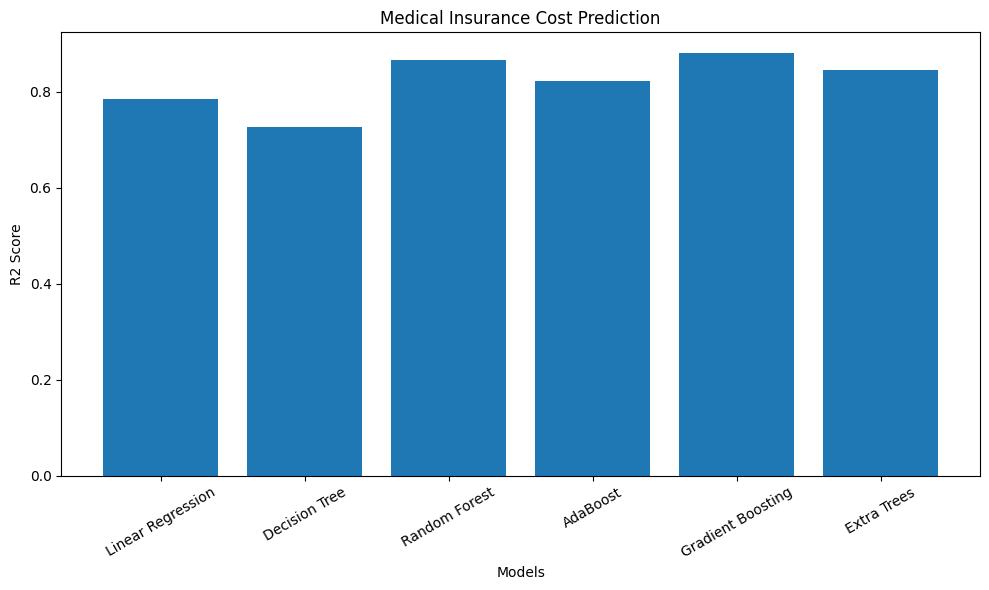

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.title("Medical Insurance Cost Prediction")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()